In [3]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.decomposition import PCA

from ucimlrepo import fetch_ucirepo
import warnings
from sklearn.exceptions import DataConversionWarning

warnings.filterwarnings("ignore", category=DataConversionWarning)


In [5]:
breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features
y = breast_cancer.data.targets

print(X.head())
print(y.head())


   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
0      0.3001          0.14710     0.2419             0.07871  ...    25.38   
1      0.0869          0.07017     0.1812             0.05667  ...    24.99   
2      0.1974          0.12790     0.2069             0.05999  ...    23.57   
3      0.2414          0.10520     0.2597             0.09744  ...    14.91   
4      0.1980          0.10430     0.1809             0.05883  ...    22.54   

   texture3  perimeter3   area3  smoothness3  compactness3  concavity3  \
0     17.33      184.60 

In [6]:
print(X.shape)
print(y.shape)

print(X.isnull().sum())


(569, 30)
(569, 1)
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
dtype: int64


In [7]:
y = y.replace({
    "M": 1,
    "B": 0
})

print(y.value_counts())


Diagnosis
0            357
1            212
dtype: int64


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

The linear kernel assumes that the classes can be separated using a straight hyperplane.
Since this dataset is relatively well separated, the linear kernel is expected to perform well.

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred)
print("Precision:", precision)

recall = recall_score(y_test, y_pred)
print("Recall:", recall)

f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

Accuracy: 0.956140350877193
Precision: 0.9318181818181818
Recall: 0.9534883720930233
F1 Score: 0.942528735632184


The model demonstrates excellent overall classification performance.
Model produces relatively few false positive predictions.
More than 95% of actual malignant tumors were correctly identified.

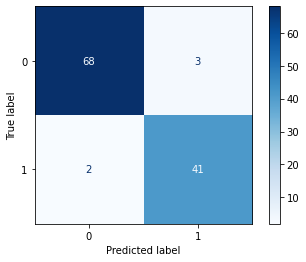

In [10]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.show()


Most benign and malignant tumors were classified correctly. Only 5 misclassifications.
This indicates that the linear SVM effectively separated the two classes.

In [11]:
param_grid = {
    'C': [0.1, 1, 10, 100]
}

grid = GridSearchCV(
    SVC(kernel='linear'),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameter:")
print(grid.best_params_)


Best Parameter:
{'C': 0.1}


Grid Search selected C = 0.1 as the optimal parameter.
A smaller C value allows a wider margin while tolerating a few classification errors.
This generally improves the model's ability to generalize to unseen data and reduces overfitting.

In [12]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_best))


Accuracy: 0.9824561403508771


Accuracy increased from 95.61% to 98.25%.
Hyperparameter tuning significantly improved model performance.
The optimized model generalized better than the default model.

In [13]:
kernels = ['linear', 'rbf', 'poly']

for kernel in kernels:

    model = SVC(kernel=kernel)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    print("\nKernel:", kernel)

    print("Accuracy:",
          accuracy_score(y_test, pred))



Kernel: linear
Accuracy: 0.956140350877193

Kernel: rbf
Accuracy: 0.9736842105263158

Kernel: poly
Accuracy: 0.868421052631579


Linear Kernel
Produced high accuracy.
Indicates that the dataset is close to being linearly separable.

RBF Kernel
Achieved the highest default accuracy.
Captures nonlinear relationships better than the linear kernel.

Polynomial Kernel
Produced the lowest accuracy.
The polynomial decision boundary may have been unnecessarily complex for this dataset.

The parameter C controls the trade-off between:
maximizing the margin, and
minimizing classification errors.

Small C (e.g., 0.1):
Allows a wider margin.
Permits a few misclassifications on the training data.
Produces a simpler model that generalizes better and reduces overfitting.

Large C (e.g., 100):
Tries to classify every training sample correctly.
Produces a narrower margin.
Can fit the training data very closely and may overfit, leading to poorer performance on unseen data.

**PCA**

In [14]:
wine = fetch_ucirepo(id=109)

X = wine.data.features
y = wine.data.targets

print(X.head())


   Alcohol  Malicacid   Ash  Alcalinity_of_ash  Magnesium  Total_phenols  \
0    14.23       1.71  2.43               15.6        127           2.80   
1    13.20       1.78  2.14               11.2        100           2.65   
2    13.16       2.36  2.67               18.6        101           2.80   
3    14.37       1.95  2.50               16.8        113           3.85   
4    13.24       2.59  2.87               21.0        118           2.80   

   Flavanoids  Nonflavanoid_phenols  Proanthocyanins  Color_intensity   Hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   0D280_0D315_of_diluted_wines  Proline  
0                        

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(X_pca[:5])


[[ 3.31675081 -1.44346263]
 [ 2.20946492  0.33339289]
 [ 2.51674015 -1.0311513 ]
 [ 3.75706561 -2.75637191]
 [ 1.00890849 -0.86983082]]


PCA compressed the information into two new variables while preserving as much variance as possible.

In [16]:
print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)


Explained Variance Ratio:
[0.36198848 0.1920749 ]


The first principal component explains approximately 36.2% of the total variance.
The second explains approximately 19.2%.
Together they explain approximately 36.20 + 19.21 = 55.41% of the total information.

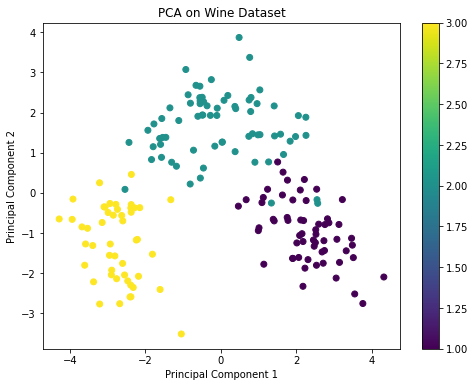

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y.squeeze(),
    cmap='viridis'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA on Wine Dataset")

plt.colorbar()

plt.show()


Three distinct clusters are visible. The classes are reasonably separated. Very little overlap exists between the clusters.

The first principal component separates the yellow cluster from the others.
The second principal component further separates the remaining classes vertically.

Since the clusters remain well separated, the first two principal components retain the most important discriminative information.

In [18]:
pca_full = PCA()

X_full = pca_full.fit_transform(X_scaled)


In [19]:
variance = pca_full.explained_variance_ratio_

print(variance)


[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


Each subsequent principal component contributes progressively less variance than the previous one.
The final principal component contributes only 0.80% of the total variance.

In [20]:
cumulative = np.cumsum(variance)

print(cumulative)


[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


The cumulative explained variance increases steadily as more principal components are added.
The first 2 principal components retain approximately 55.41% of the total variance.
The first 5 principal components retain approximately 80.16% of the total variance, and so on.

In [21]:
components = np.argmax(cumulative >= 0.95) + 1

print("Components required:", components)


Components required: 10


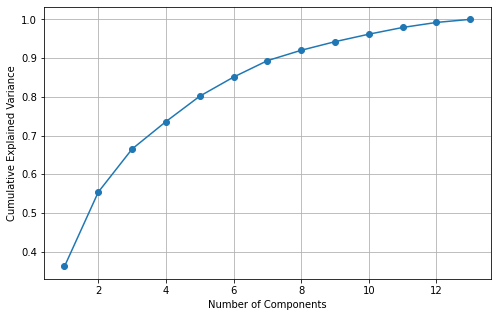

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative)+1),
    cumulative,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.grid(True)

plt.show()


The cumulative explained variance increases rapidly for the first few principal components.
After approximately 10 components, the cumulative variance exceeds 95%.
Beyond this point, adding more components contributes very little additional information.


Approximately 10 principal components are required to retain at least 95% of the total variance.
Therefore, reducing directly to 2 components is useful for visualization but does not preserve all the information in the dataset.

In [23]:
print("Original Features :", X.shape[1])

print("Reduced Features :", X_pca.shape[1])


Original Features : 13
Reduced Features : 2


PCA reduced the feature count from 13 to 2.
The first two principal components retained most of the important information.

Around 95% variance required several (10) principal components.

Dimensionality reduction made visualization easier and reduced computational complexity.

PCA is useful for feature extraction but may reduce interpretability since principal components are linear combinations of the original features.
